### IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### LOADIND DATA

In [2]:
DATA = pd.read_csv('nyc_taxi_trip_duration.csv')

In [3]:
DATA.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,2016-02-29 16:40:21,2016-02-29 16:47:01,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,2016-03-11 23:35:37,2016-03-11 23:53:57,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,2016-02-21 17:59:33,2016-02-21 18:26:48,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,2016-01-05 09:44:31,2016-01-05 10:03:32,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,2016-02-17 06:42:23,2016-02-17 06:56:31,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [4]:
DATA.dtypes

id                     object
vendor_id               int64
pickup_datetime        object
dropoff_datetime       object
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag     object
trip_duration           int64
dtype: object

### EDITING AND ADDING DATA

In [5]:
DATA['vendor_id'] = DATA['vendor_id'].astype('category')
DATA['store_and_fwd_flag'] = DATA['store_and_fwd_flag'].astype('category')

In [6]:
# Converting to pandas datetime
DATA['pickup_datetime'] = pd.to_datetime(DATA['pickup_datetime'])
DATA['dropoff_datetime'] = pd.to_datetime(DATA['dropoff_datetime'])

In [7]:
DATA['day_of_week'] = DATA['pickup_datetime'].dt.weekday
DATA['hour_of_day'] = DATA['pickup_datetime'].dt.hour

In [8]:
dlon = DATA["pickup_longitude"] - DATA["dropoff_longitude"]
dlat = DATA["pickup_latitude"] - DATA["dropoff_latitude"]
a = (np.sin(dlat/2))**2 + np.cos(DATA["pickup_latitude"]) * np.cos(DATA["dropoff_latitude"]) * (np.sin(dlon/2))**2
c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
DATA["distance"] = 6373.0 * c

In [9]:
DATA.dtypes

id                            object
vendor_id                   category
pickup_datetime       datetime64[ns]
dropoff_datetime      datetime64[ns]
passenger_count                int64
pickup_longitude             float64
pickup_latitude              float64
dropoff_longitude            float64
dropoff_latitude             float64
store_and_fwd_flag          category
trip_duration                  int64
day_of_week                    int64
hour_of_day                    int64
distance                     float64
dtype: object

### UNIVARIATE ANALYSIS

#### CONTINOUS VARIABLES

In [10]:
def uni_cont(data, var):
    plt.figure(figsize=(20, 5))
    mini = data[var].min()
    maxi = data[var].max()
    mean = data[var].mean()
    median = data[var].median()
    std = data[var].std()
    skew = data[var].skew()
    kurtosis = data[var].kurtosis()
    sns.kdeplot(data[var])
    sns.scatterplot([mini, maxi], [0, 0], color="green", label="min/max")
    sns.scatterplot([mean], [0], color="red", label="mean")
    sns.scatterplot([median], [0], color="blue", label="mode")
    plt.ylabel("density")
    plt.xlabel(var)
    plt.title("std = {} kurtosis = {} skew = {} mean = {} median = {}".format(round(std,3), round(kurtosis,3), round(skew,3), round(mean,3), round(median,3)))

##### PICKUP LONGITUDE

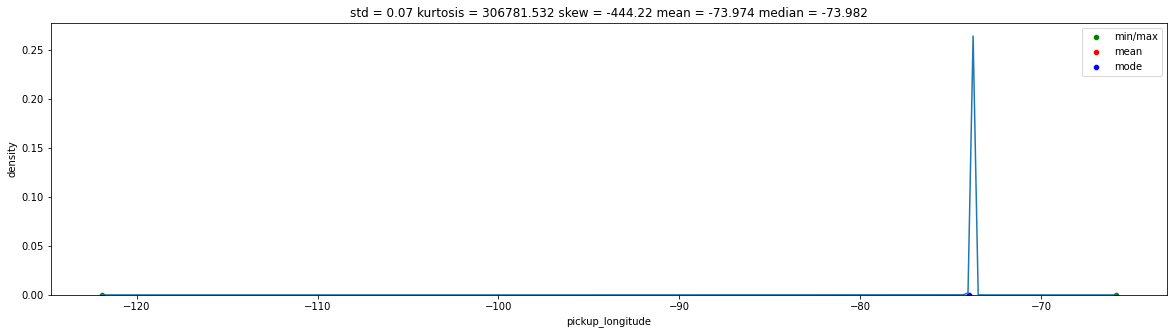

In [11]:
uni_cont(DATA, "pickup_longitude")

High Kustosis value and high negative skew indicating significant pickups from the west of high dense pickups

##### PICKUP LATITUDE

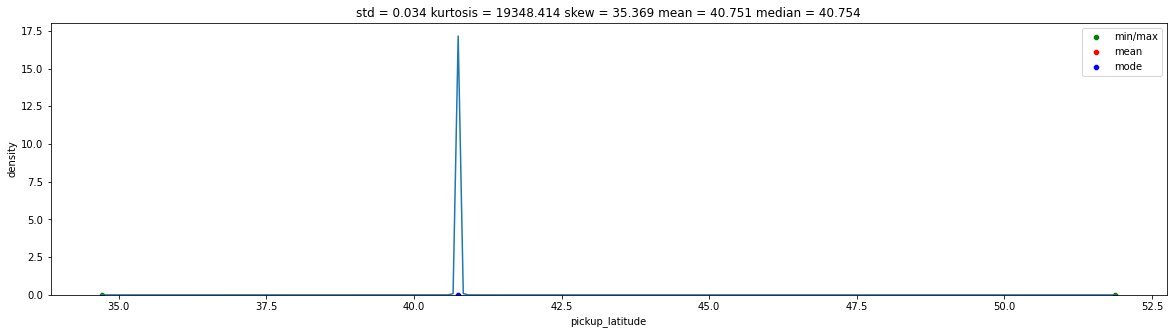

In [12]:
uni_cont(DATA, "pickup_latitude")

High Kustosis value and High Negative Skew indicating significant pickups from the north of high dense pickups

##### DROPOFF LONGITUDE

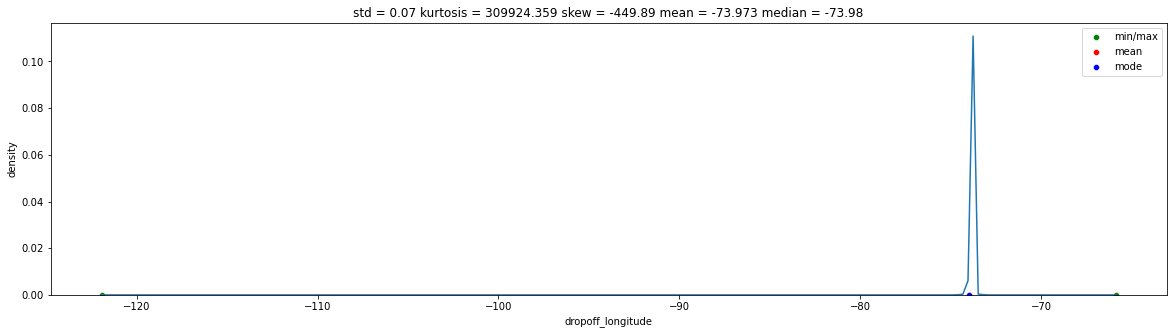

In [13]:
uni_cont(DATA, "dropoff_longitude")

High Kustosis value and Negative Skew indicating significant dropoffs from the west of high dense dropoffs

##### DROPOFF LATITUDE

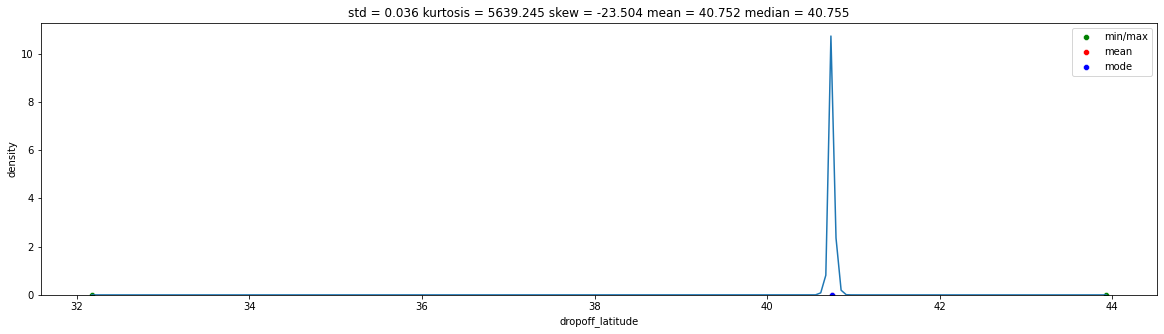

In [14]:
uni_cont(DATA, "dropoff_latitude")

High Kustosis value and Negative Skew indicating significant dropoffs from the south of high dense dropoffs

##### MAKING THE DATA LESS DENSE

In [15]:
df_new = DATA.loc[(DATA.pickup_latitude > 40.6) & (DATA.pickup_latitude < 40.9)]
df_new = df_new.loc[(df_new.dropoff_latitude>40.6) & (df_new.dropoff_latitude < 40.9)]
df_new = df_new.loc[(df_new.dropoff_longitude > -74.05) & (df_new.dropoff_longitude < -73.7)]
df_new = df_new.loc[(df_new.pickup_longitude > -74.05) & (df_new.pickup_longitude < -73.7)]

##### PICKUP LONGITUDE

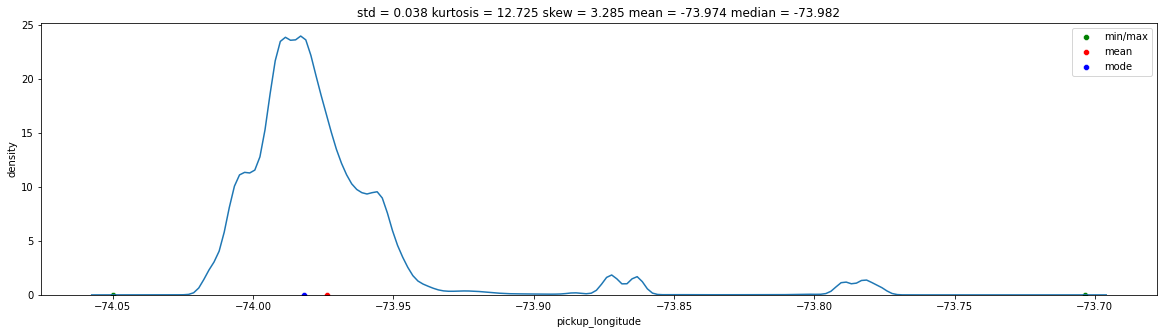

In [16]:
uni_cont(df_new, "pickup_longitude")

##### PICKUP LATITUDE

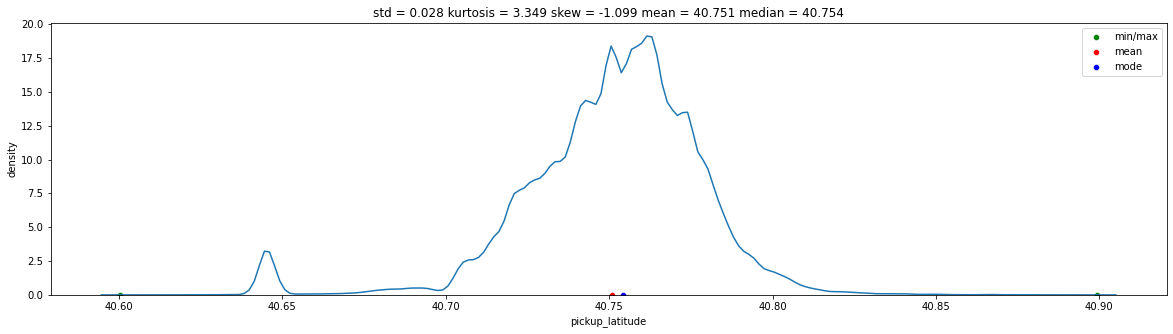

In [17]:
uni_cont(df_new, "pickup_latitude")

##### DROPOFF LONGITUDE

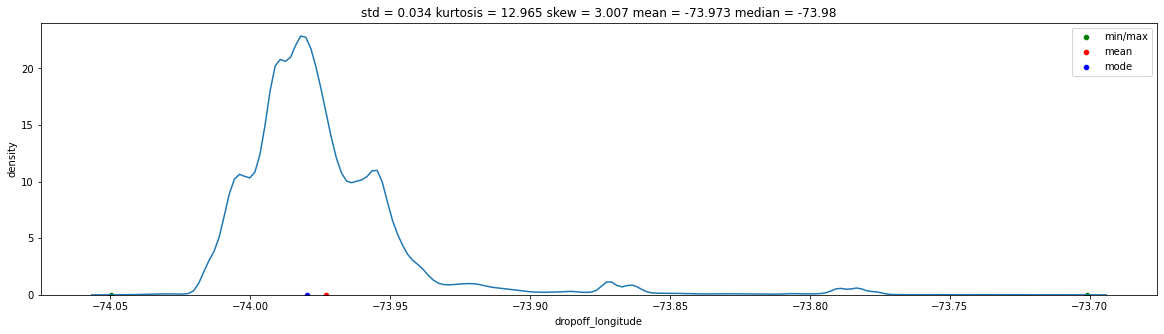

In [18]:
uni_cont(df_new, "dropoff_longitude")

##### DROPOFF LATITUDE

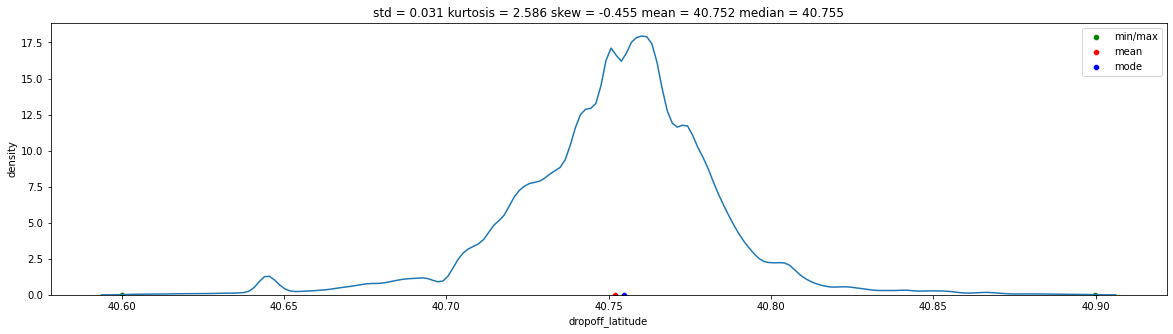

In [19]:
uni_cont(df_new, "dropoff_latitude")

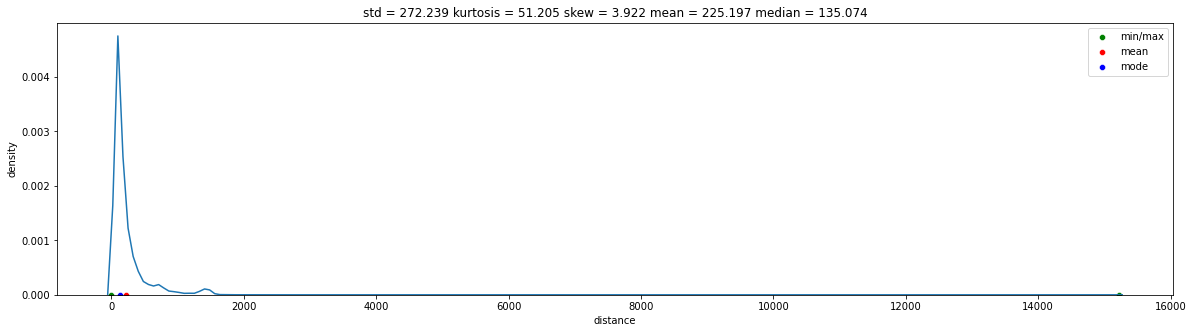

In [20]:
uni_cont(DATA, "distance")

More number of trips with less than 1000 distance as kurtosis there are less outliers

##### TRIP DURATION

<Figure size 1440x360 with 0 Axes>

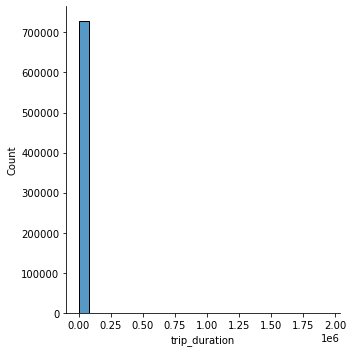

In [21]:
plt.figure(figsize=(20, 5))
sns.displot(DATA['trip_duration'], kde = False, bins = 25)
plt.show()

The data is not normal<br>
Normalize it using log of data

In [22]:
DATA['trip_duration_log'] = np.log1p(DATA['trip_duration'])

<Figure size 1440x360 with 0 Axes>

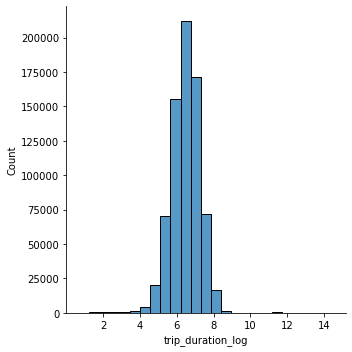

In [23]:
plt.figure(figsize=(20, 5))
sns.displot(DATA['trip_duration_log'], kde = False, bins = 25)
plt.show()

#### CATEGORICAL

In [24]:
def uni_cat(var):
    plt.figure(figsize=(20, 5))
    summary = pd.DataFrame(DATA.groupby([var])['id'].count())
    summary.reset_index(inplace = True)
    b = sns.barplot(list(summary.values[:,0]), list(summary.values[:,1]))
    for index, row in summary.iterrows():
        b.text(row.name, row.id, row.id, color='black', ha="center")
    plt.show()

##### PASSENGER COUNT

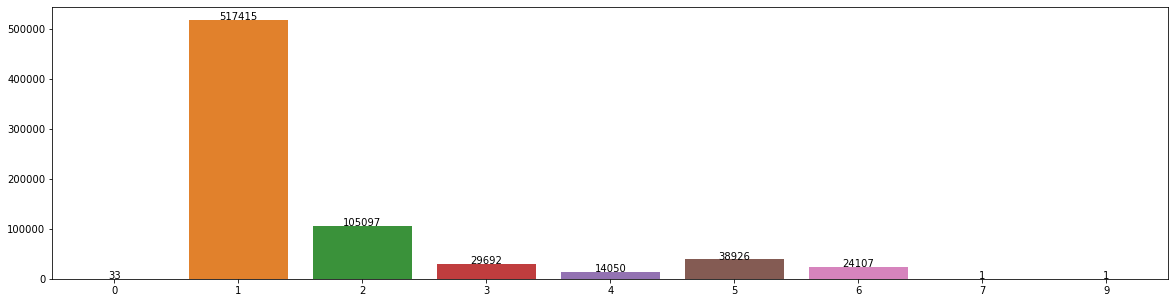

In [25]:
uni_cat('passenger_count')

Higher number of trips with one passenger

##### VENDOR ID

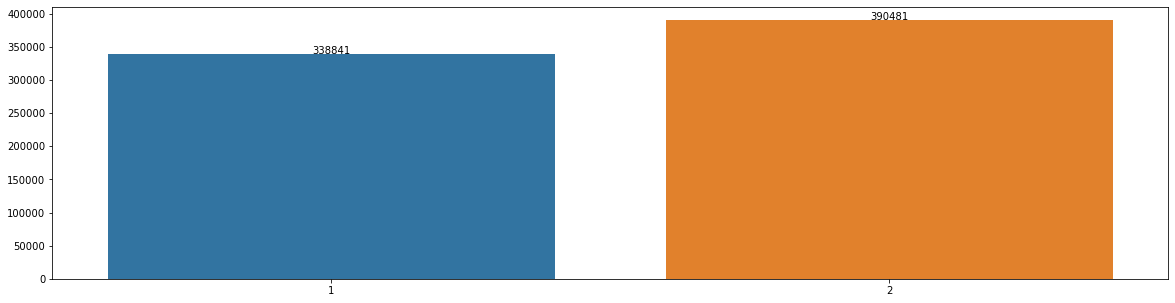

In [26]:
uni_cat('vendor_id')

More number of trips with vendor 2

#####  STORE AND FORWARD FLAG

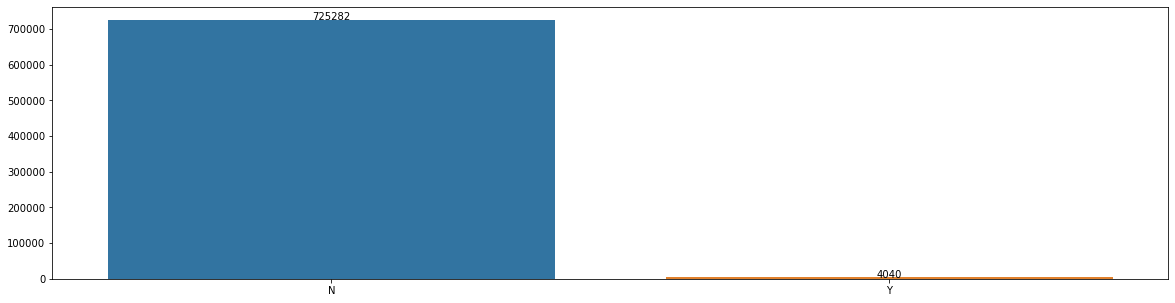

In [27]:
uni_cat('store_and_fwd_flag')

Very less number of trips with no network

##### Day of week

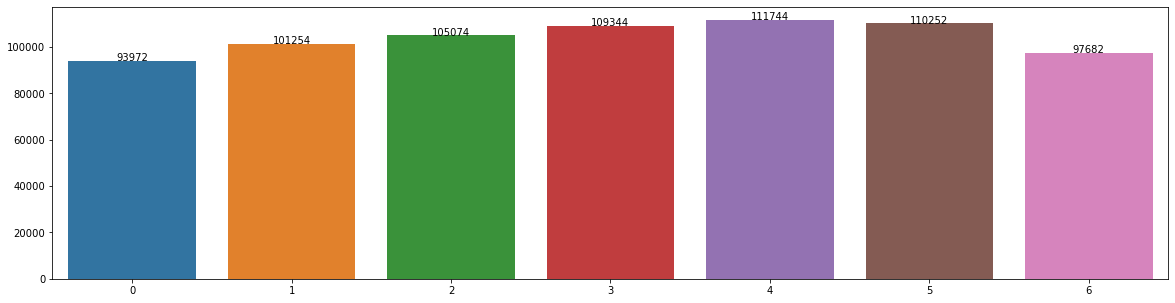

In [28]:
uni_cat('day_of_week')

More trips during the week

##### HOUR OF DAY

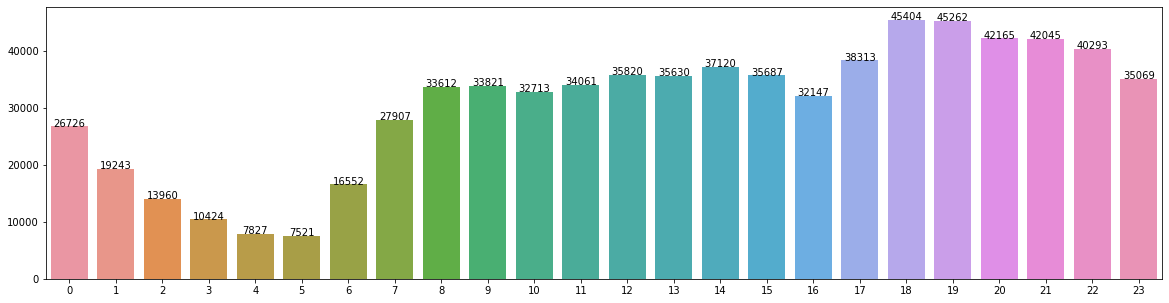

In [29]:
uni_cat('hour_of_day')

Less no of trips after midnight and max no of trips at night

### BIVARIATE ANALYSIS

#### CONTINOUS - CONTINOUS

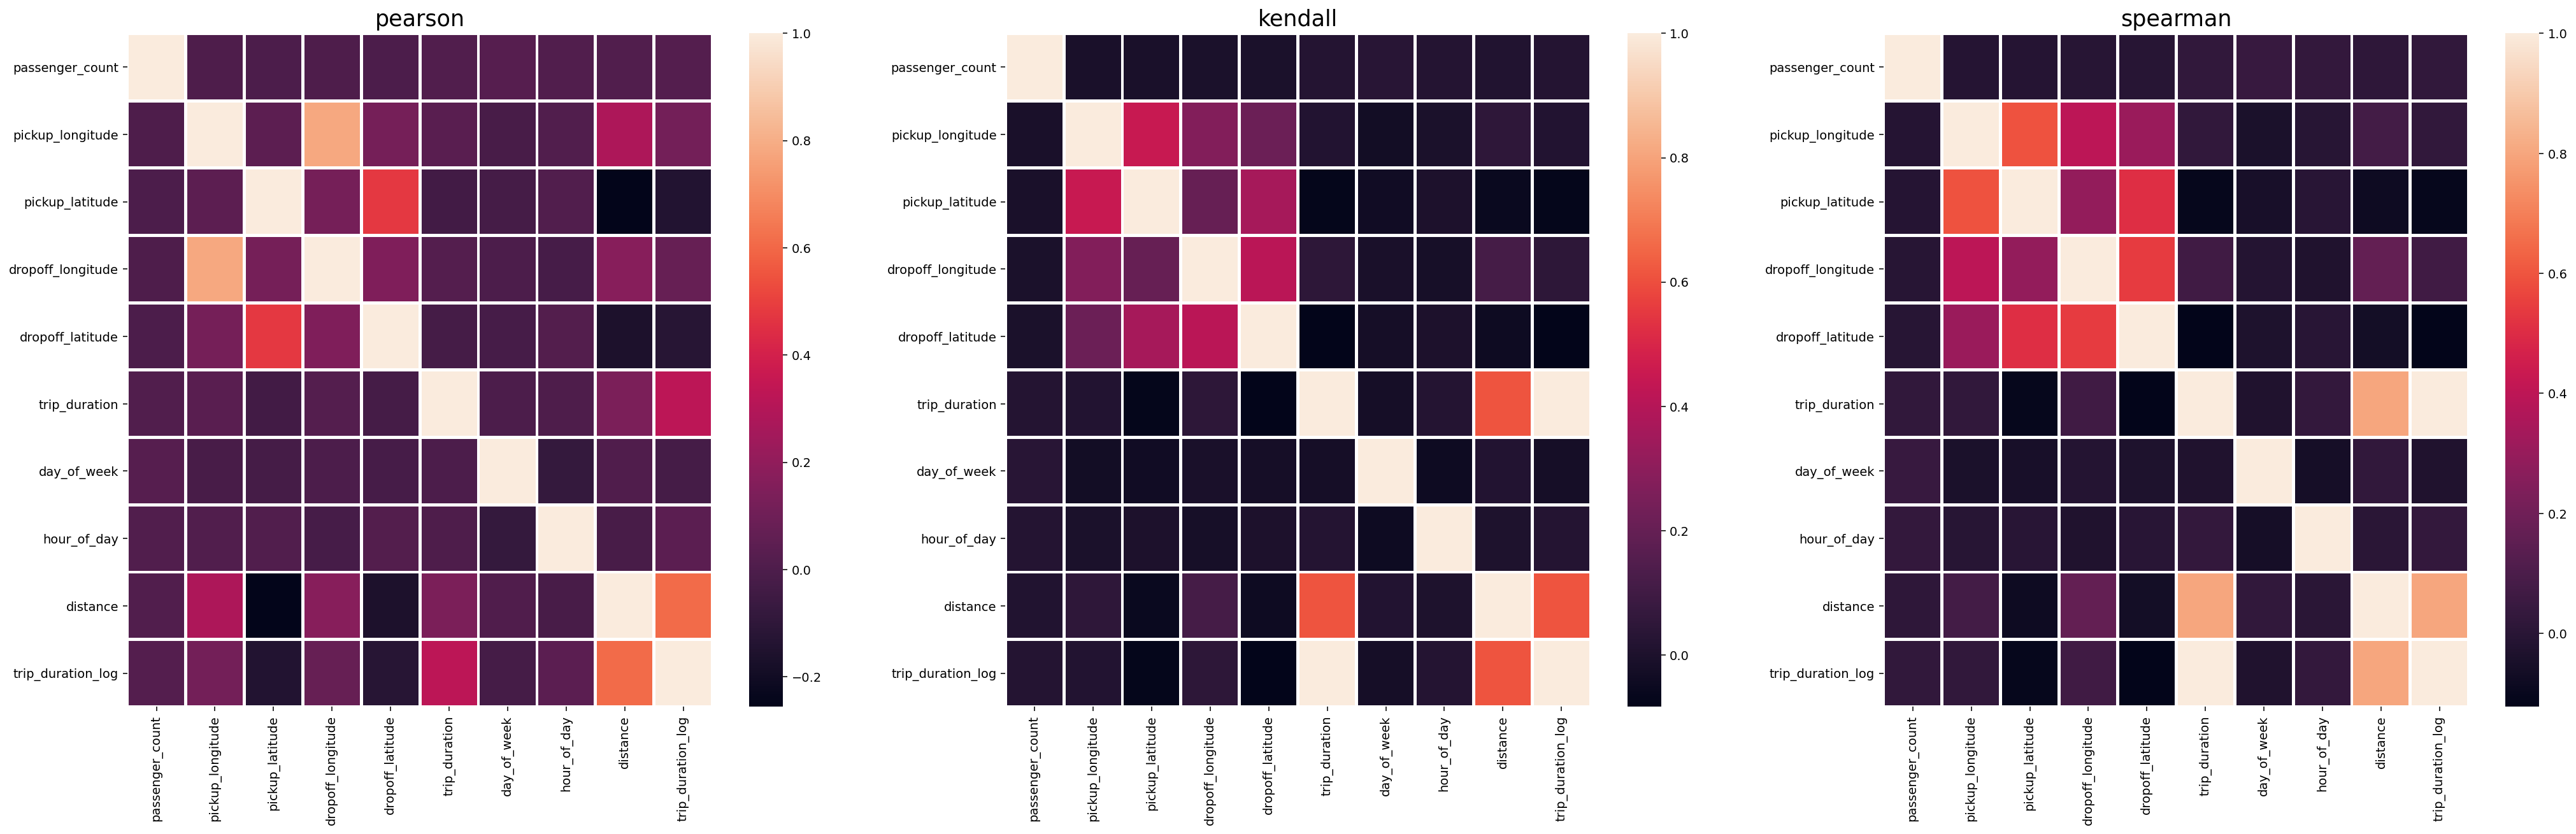

In [30]:
plt.figure(figsize=(36,10), dpi=140)
for j, i in enumerate(["pearson", "kendall", "spearman"]):
    plt.subplot(1, 3, j+1)
    corr = DATA.select_dtypes(["int64", "float64"]).dropna().corr(method=i)
    sns.heatmap(corr, linewidth=2)
    plt.title(i, fontsize=18)

No variables are correlated hence no two variables affect the dependent variable equally</b>
Dropoff and pickup longitude are correlated but dropoff variable is removed later as it is not available during start of trip

#### CONTINOUS - CATEGORICAL

In [31]:
def cont_cat(var):
    plt.figure(figsize=(20, 5))
    summary = pd.DataFrame(DATA.groupby([var])['trip_duration'].median())
    summary.reset_index(inplace = True)
    b = sns.barplot(list(summary.values[:,0]), list(summary.values[:,1]))
    for index, row in summary.iterrows():
        b.text(row.name, row.trip_duration, row.trip_duration, color='black', ha="center")
    plt.show()

##### STORE AND FORWARD FLAG

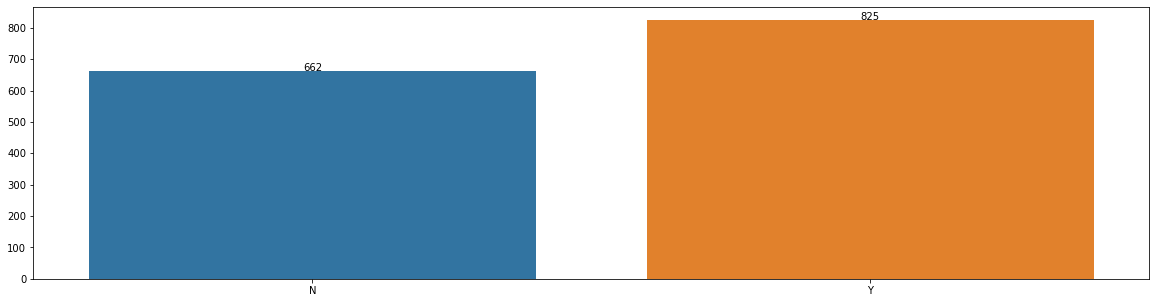

In [32]:
cont_cat('store_and_fwd_flag')

Median duration of trips with no network is more

##### PASSENGER COUNT

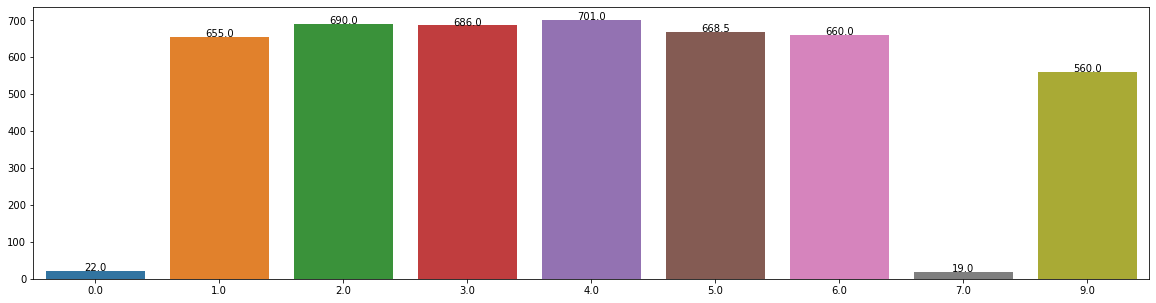

In [33]:
cont_cat('passenger_count')

Very less median duration of trips with 0 or 7 passengers

##### DAY OF WEEK

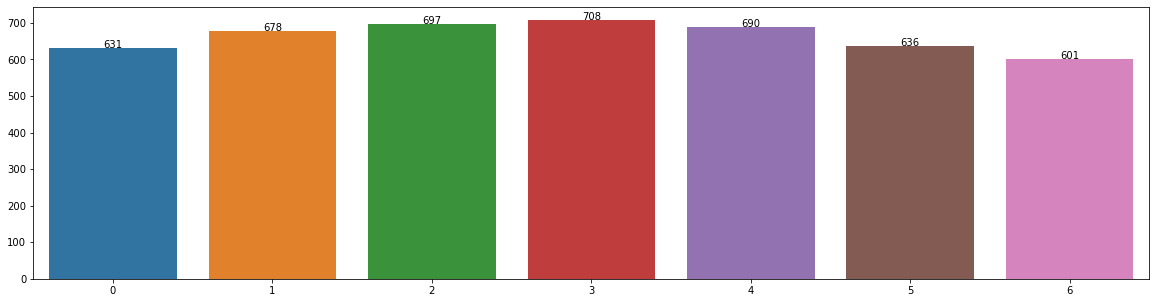

In [34]:
cont_cat('day_of_week')

Higher median duration of trips during weekdays

##### VENDOR ID

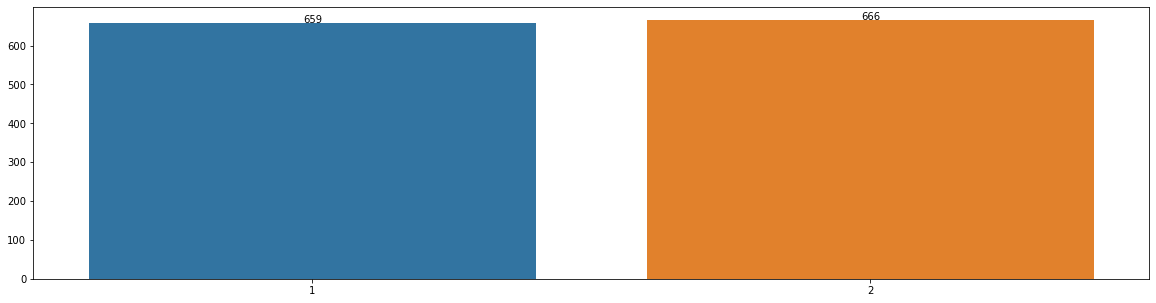

In [35]:
cont_cat('vendor_id')

Vendor id 2 has relatively more median duration of trips

##### HOUR OF DAY

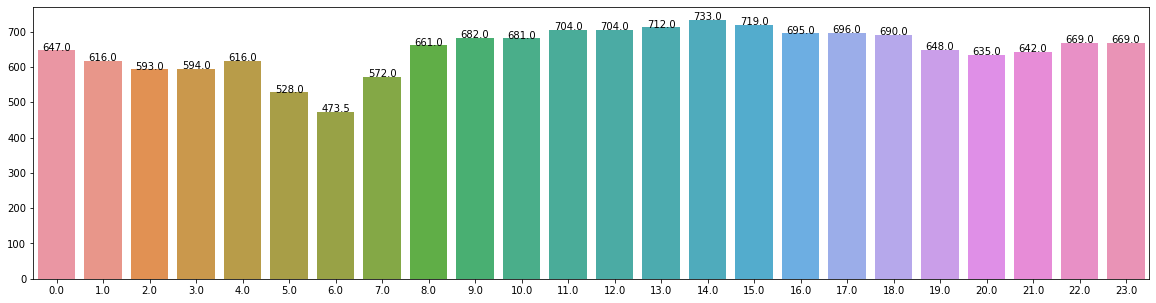

In [36]:
cont_cat('hour_of_day')

Less number of median duration of trips in the morning

#### CATEGORICAL CATEGORICAL

In [37]:
DATA.pivot_table('trip_duration', ['vendor_id', 'store_and_fwd_flag'], 'day_of_week', aggfunc='median')

day_of_week                       0      1      2      3      4      5      6
vendor_id store_and_fwd_flag                                                 
1         N                   627.0  673.0  688.0  698.0  687.0  632.0  598.0
          Y                   862.0  871.0  876.5  904.0  836.0  700.0  689.5
2         N                   632.0  682.0  703.0  716.0  693.0  639.0  605.0